In [1]:
#!pip install --no-cache-dir torch-scatter -f https://data.pyg.org/whl/torch-2.6.0+cu126.html
#!pip install --no-cache-dir torch-sparse -f https://data.pyg.org/whl/torch-2.6.0+cu126.html
#!pip install --no-cache-dir torch-geometric
#!pip install --no-cache-dir -q git+https://github.com/snap-stanford/deepsnap.git

In [1]:
import networkx as nx
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from dominating_set_algorithms import *

In [2]:
# import required modules
import random
from tqdm import tqdm
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

import torch
from torch import nn, optim, Tensor

from torch_sparse import SparseTensor, matmul

from torch_geometric.utils import structured_negative_sampling
from torch_geometric.data import download_url, extract_zip
from torch_geometric.nn.conv.gcn_conv import gcn_norm
from torch_geometric.nn.conv import MessagePassing
from torch_geometric.typing import Adj

/home/jetson/paco/gnn-ds/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
# setup
import torch
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device {device}.")

Using device cpu.


In [4]:
# download the dataset
# url = 'https://files.grouplens.org/datasets/movielens/ml-latest-small.zip'
# extract_zip(download_url(url, '.'), '.')

movie_path = './ml-latest-small/movies.csv'
rating_path = './ml-latest-small/ratings.csv'

#movie_path = './ml-1m/movies.dat'
#rating_path = './ml-1m/ratings.dat'

In [5]:
from data_handling import *

#user_mapping = load_node_csv(rating_path, index_col=0, header=None, delimiter='::', col_names=['movieId', 'rating',	'timestamp'], index_name='userId')
#movie_mapping = load_node_csv(movie_path, index_col=0, header=None, delimiter='::', col_names=['title', 'genres'], index_name='movieId')

user_mapping = load_node_csv(rating_path, index_col='userId')
movie_mapping = load_node_csv(movie_path, index_col='movieId')

In [6]:
for key in movie_mapping:
    movie_mapping[key] += len(user_mapping)

len(user_mapping), len(movie_mapping)

(610, 9742)

In [7]:
edge_index = load_edge_csv(
    rating_path,
    src_index_col='userId',
    src_mapping=user_mapping,
    dst_index_col='movieId',
    dst_mapping=movie_mapping,
    link_index_col='rating',
    rating_threshold=3,
)

edge_index.shape

torch.Size([2, 81763])

# Dominating Sets

In [8]:
# users = ['u' + str(u) for u in edge_index.tolist()[0]]
# items = ['i' + str(i) for i in edge_index.tolist()[1]]

# G = nx.Graph()
# G.add_nodes_from(users, bipartite=0)
# G.add_nodes_from(items, bipartite=1)
# G.add_edges_from(zip(users,items))

# print('Number of nodes: ', G.number_of_nodes())
# print('Number of edges: ', G.number_of_edges())

In [9]:
# dom_set = dominating_set(G,1,optimize=True)

# print('Number of nodes: ', len(dom_set))
# print('Ratio: ', len(dom_set) / G.number_of_nodes())

In [10]:
# ds_users, ds_movies = [], []

# for element in dom_set:
#   if element.startswith('u'):
#     ds_users.append(int(element[1:]))
#   elif element.startswith('i'):
#     ds_movies.append(int(element[1:]))

# len(ds_users), len(ds_movies)

In [11]:
# ds_indices = torch.logical_or(torch.isin(edge_index[0], torch.tensor(ds_users)),
#                               torch.isin(edge_index[1], torch.tensor(ds_movies))).nonzero().reshape(-1).tolist()

# len(ds_indices)

In [12]:
# my_list = ds_indices
# file_name = "c1_indices.txt"

# with open(file_name, 'w') as f:
#     for item in my_list:
#         f.write(f"{item}\n")

In [13]:
def import_txt(file_name):
    with open(file_name, 'r') as file:
        data = file.read().splitlines()
        data = [int(x) for x in data]

        return data

ds_users = import_txt('c1_users.txt')
ds_movies = import_txt('c1_movies.txt')
ds_movies = [x + 6040 for x in ds_movies]
ds_indices = import_txt('c1_indices.txt')

In [14]:
# split the edges of the graph using a 80/10/10 train/validation/test split
num_users, num_movies = len(user_mapping), len(movie_mapping)
num_interactions = edge_index.shape[1]
all_indices = [i for i in range(num_interactions)]

train_indices, test_indices = train_test_split(
    all_indices, test_size=0.2, random_state=1)
val_indices, test_indices = train_test_split(
    test_indices, test_size=0.5, random_state=1)

#train_indices = list(set(train_indices) & set(ds_indices))
#train_indices = random.sample(train_indices, 54402)

train_edge_index = edge_index[:, train_indices]
val_edge_index = edge_index[:, val_indices]
test_edge_index = edge_index[:, test_indices]

train_edge_index.shape

torch.Size([2, 65410])

In [15]:
# convert edge indices into Sparse Tensors: https://pytorch-geometric.readthedocs.io/en/latest/notes/sparse_tensor.html
train_sparse_edge_index = SparseTensor(row=torch.cat([train_edge_index[0],train_edge_index[1]]), 
                                       col=torch.cat([train_edge_index[1],train_edge_index[0]]), 
                                       sparse_sizes=(num_users + num_movies, num_users + num_movies))
val_sparse_edge_index = SparseTensor(row=torch.cat([val_edge_index[0],val_edge_index[1]]), 
                                     col=torch.cat([val_edge_index[1],val_edge_index[0]]), 
                                     sparse_sizes=(num_users + num_movies, num_users + num_movies))
test_sparse_edge_index = SparseTensor(row=torch.cat([test_edge_index[0],test_edge_index[1]]), 
                                      col=torch.cat([test_edge_index[1],test_edge_index[0]]), 
                                     sparse_sizes=(num_users + num_movies, num_users + num_movies))

In [13]:
# define constants
from gcn_model import *
#import optuna

model = LightGCN(num_users, num_movies)

#study = optuna.load_study(study_name="c3dsOpt", storage="sqlite:///db.sqlite3")
#best_params = study.best_params

#ITERATIONS = 10000
#BATCH_SIZE = 1024
#LR = best_params['lr']
#ITERS_PER_EVAL = 200
#ITERS_PER_LR_DECAY = 200
#K = 20
#LAMBDA = best_params['lambda_val']

ITERATIONS = 10000
BATCH_SIZE = 1024
LR = 1e-3
ITERS_PER_EVAL = 200
ITERS_PER_LR_DECAY = 200
K = 20
LAMBDA = 1e-6

optimizer = optim.Adam(model.parameters(), lr=LR)
scheduler = optim.lr_scheduler.ExponentialLR(optimizer, gamma=0.95)

#model = LightGCN(num_users, num_movies, best_params['embedding_dim'], best_params['K'])

In [14]:
# setup
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device {device}.")

model = model.to(device)
model.train()

#optimizer = getattr(optim, best_params['optimizer'])(model.parameters(), lr=LR)
#scheduler = optim.lr_scheduler.ExponentialLR(optimizer, gamma=0.95)

edge_index = edge_index.to(device)
train_edge_index = train_edge_index.to(device)
train_sparse_edge_index = train_sparse_edge_index.to(device)

val_edge_index = val_edge_index.to(device)
val_sparse_edge_index = val_sparse_edge_index.to(device)

train_edge_index_no_offset = train_edge_index.clone().detach()
train_edge_index_no_offset[1] = train_edge_index_no_offset[1] - len(user_mapping)

val_edge_index_no_offset = val_edge_index.clone().detach()
val_edge_index_no_offset[1] = val_edge_index_no_offset[1] - len(user_mapping)

Using device cuda.


In [15]:
# training loop
train_losses = []
val_losses = []

for iter in range(ITERATIONS):
    # forward propagation
    users_emb_final, users_emb_0, items_emb_final, items_emb_0 = model.forward(
        train_sparse_edge_index)

    # mini batching
    user_indices, pos_item_indices, neg_item_indices = sample_mini_batch(
        BATCH_SIZE, train_edge_index_no_offset)
    user_indices, pos_item_indices, neg_item_indices = user_indices.to(
        device), pos_item_indices.to(device), neg_item_indices.to(device)
    users_emb_final, users_emb_0 = users_emb_final[user_indices], users_emb_0[user_indices]
    pos_items_emb_final, pos_items_emb_0 = items_emb_final[pos_item_indices], items_emb_0[pos_item_indices]
    neg_items_emb_final, neg_items_emb_0 = items_emb_final[neg_item_indices], items_emb_0[neg_item_indices]

    # loss computation
    train_loss = bpr_loss(users_emb_final, users_emb_0, pos_items_emb_final,
                          pos_items_emb_0, neg_items_emb_final, neg_items_emb_0, LAMBDA)

    optimizer.zero_grad()
    train_loss.backward()
    optimizer.step()

    if iter % ITERS_PER_EVAL == 0:
        model.eval()
        val_loss, recall, precision, ndcg = evaluation(
            model, val_edge_index_no_offset, val_sparse_edge_index, [train_edge_index_no_offset], K, LAMBDA)
        print(f"[Iteration {iter}/{ITERATIONS}] train_loss: {round(train_loss.item(), 5)}, val_loss: {round(val_loss, 5)}, val_recall@{K}: {round(recall, 5)}, val_precision@{K}: {round(precision, 5)}, val_ndcg@{K}: {round(ndcg, 5)}")
        train_losses.append(train_loss.item())
        val_losses.append(val_loss)
        model.train()

    if iter % ITERS_PER_LR_DECAY == 0 and iter != 0:
        scheduler.step()

[Iteration 0/10000] train_loss: -0.6923, val_loss: -0.68719, val_recall@20: 0.00098, val_precision@20: 0.00111, val_ndcg@20: 0.00128
[Iteration 200/10000] train_loss: -5.69876, val_loss: -4.85163, val_recall@20: 0.06843, val_precision@20: 0.03339, val_ndcg@20: 0.05421
[Iteration 400/10000] train_loss: -23.81303, val_loss: -19.94671, val_recall@20: 0.07921, val_precision@20: 0.03927, val_ndcg@20: 0.07026
[Iteration 600/10000] train_loss: -53.21337, val_loss: -41.87497, val_recall@20: 0.09387, val_precision@20: 0.04438, val_ndcg@20: 0.08139
[Iteration 800/10000] train_loss: -82.53329, val_loss: -69.92638, val_recall@20: 0.10941, val_precision@20: 0.05221, val_ndcg@20: 0.09551
[Iteration 1000/10000] train_loss: -122.33769, val_loss: -101.29727, val_recall@20: 0.10831, val_precision@20: 0.05136, val_ndcg@20: 0.09875
[Iteration 1200/10000] train_loss: -168.26962, val_loss: -134.18565, val_recall@20: 0.11531, val_precision@20: 0.05375, val_ndcg@20: 0.10199
[Iteration 1400/10000] train_loss: 

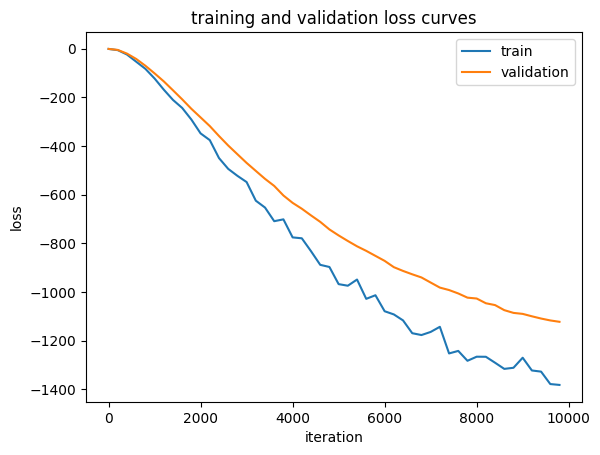

In [16]:
iters = [iter * ITERS_PER_EVAL for iter in range(len(train_losses))]
plt.plot(iters, train_losses, label='train')
plt.plot(iters, val_losses, label='validation')
plt.xlabel('iteration')
plt.ylabel('loss')
plt.title('training and validation loss curves')
plt.legend()
plt.show()

In [17]:
# evaluate on test set
model.eval()

test_edge_index = test_edge_index.to(device)
test_sparse_edge_index = test_sparse_edge_index.to(device)

test_edge_index_no_offset = test_edge_index.clone().detach()
test_edge_index_no_offset[1] = test_edge_index_no_offset[1] - len(user_mapping)

test_loss, test_recall, test_precision, test_ndcg = evaluation(
    model, test_edge_index_no_offset, test_sparse_edge_index, [train_edge_index_no_offset, val_edge_index_no_offset], K, LAMBDA)

print(f"[test_loss: {round(test_loss, 5)}, test_recall@{K}: {round(test_recall, 5)}, test_precision@{K}: {round(test_precision, 5)}, test_ndcg@{K}: {round(test_ndcg, 5)}")

[test_loss: -1120.12256, test_recall@20: 0.1278, test_precision@20: 0.0587, test_ndcg@20: 0.11064


# Make New Recommendatios for a Given User

In [ ]:
model.eval()
df = pd.read_csv(movie_path)
movieid_title = pd.Series(df.title.values,index=df.movieId).to_dict()
movieid_genres = pd.Series(df.genres.values,index=df.movieId).to_dict()

user_pos_items = get_user_positive_items(edge_index)

In [67]:
def make_predictions(user_id, num_recs):
    user = user_mapping[user_id]
    e_u = model.users_emb.weight[user]
    scores = model.items_emb.weight @ e_u

    values, indices = torch.topk(scores, k=len(user_pos_items[user]) + num_recs)
    indices += len(user_mapping)

    movies = [index.cpu().item() for index in indices if index in user_pos_items[user]][:num_recs]
    movie_ids = [list(movie_mapping.keys())[list(movie_mapping.values()).index(movie)] for movie in movies]
    titles = [movieid_title[id] for id in movie_ids]
    genres = [movieid_genres[id] for id in movie_ids]

    print(f"Here are some movies that user {user_id} rated highly")
    for i in range(num_recs):
        print(f"title: {titles[i]}, genres: {genres[i]} ")

    print()

    movies = [index.cpu().item() for index in indices if index not in user_pos_items[user]][:num_recs]
    movie_ids = [list(movie_mapping.keys())[list(movie_mapping.values()).index(movie)] for movie in movies]
    titles = [movieid_title[id] for id in movie_ids]
    genres = [movieid_genres[id] for id in movie_ids]

    print(f"Here are some suggested movies for user {user_id}")
    for i in range(num_recs):
        print(f"title: {titles[i]}, genres: {genres[i]} ")

In [68]:
USER_ID = 1
NUM_RECS = 10

make_predictions(USER_ID, NUM_RECS)

Here are some movies that user 1 rated highly
title: Forrest Gump (1994), genres: Comedy|Drama|Romance|War 
title: Silence of the Lambs, The (1991), genres: Crime|Horror|Thriller 
title: Schindler's List (1993), genres: Drama|War 
title: Pulp Fiction (1994), genres: Comedy|Crime|Drama|Thriller 
title: Star Wars: Episode IV - A New Hope (1977), genres: Action|Adventure|Sci-Fi 
title: Jurassic Park (1993), genres: Action|Adventure|Sci-Fi|Thriller 
title: Matrix, The (1999), genres: Action|Sci-Fi|Thriller 
title: Batman (1989), genres: Action|Crime|Thriller 
title: Fugitive, The (1993), genres: Thriller 
title: Braveheart (1995), genres: Action|Drama|War 

Here are some suggested movies for user 1
title: Shawshank Redemption, The (1994), genres: Crime|Drama 
title: Apollo 13 (1995), genres: Adventure|Drama|IMAX 
title: Terminator 2: Judgment Day (1991), genres: Action|Sci-Fi 
title: Aladdin (1992), genres: Adventure|Animation|Children|Comedy|Musical 
title: Good Will Hunting (1997), genre

In [69]:
USER_ID = 414
NUM_RECS = 10

make_predictions(USER_ID, NUM_RECS)

Here are some movies that user 414 rated highly
title: Shawshank Redemption, The (1994), genres: Crime|Drama 
title: Forrest Gump (1994), genres: Comedy|Drama|Romance|War 
title: Silence of the Lambs, The (1991), genres: Crime|Horror|Thriller 
title: Schindler's List (1993), genres: Drama|War 
title: Pulp Fiction (1994), genres: Comedy|Crime|Drama|Thriller 
title: Apollo 13 (1995), genres: Adventure|Drama|IMAX 
title: Terminator 2: Judgment Day (1991), genres: Action|Sci-Fi 
title: Star Wars: Episode IV - A New Hope (1977), genres: Action|Adventure|Sci-Fi 
title: Jurassic Park (1993), genres: Action|Adventure|Sci-Fi|Thriller 
title: Matrix, The (1999), genres: Action|Sci-Fi|Thriller 

Here are some suggested movies for user 414
title: Ace Ventura: Pet Detective (1994), genres: Comedy 
title: Sleepless in Seattle (1993), genres: Comedy|Drama|Romance 
title: Batman Forever (1995), genres: Action|Adventure|Comedy|Crime 
title: Waterworld (1995), genres: Action|Adventure|Sci-Fi 
title: Har

In [70]:
USER_ID = 52
NUM_RECS = 10

make_predictions(USER_ID, NUM_RECS)

Here are some movies that user 52 rated highly
title: Shawshank Redemption, The (1994), genres: Crime|Drama 
title: Forrest Gump (1994), genres: Comedy|Drama|Romance|War 
title: Apollo 13 (1995), genres: Adventure|Drama|IMAX 
title: Star Wars: Episode IV - A New Hope (1977), genres: Action|Adventure|Sci-Fi 
title: Matrix, The (1999), genres: Action|Sci-Fi|Thriller 
title: Aladdin (1992), genres: Adventure|Animation|Children|Comedy|Musical 
title: Good Will Hunting (1997), genres: Drama|Romance 
title: Fight Club (1999), genres: Action|Crime|Drama|Thriller 
title: Star Wars: Episode V - The Empire Strikes Back (1980), genres: Action|Adventure|Sci-Fi 
title: Lord of the Rings: The Return of the King, The (2003), genres: Action|Adventure|Drama|Fantasy 

Here are some suggested movies for user 52
title: Silence of the Lambs, The (1991), genres: Crime|Horror|Thriller 
title: Schindler's List (1993), genres: Drama|War 
title: Pulp Fiction (1994), genres: Comedy|Crime|Drama|Thriller 
title: T